In [1]:
import numpy as np 
import pandas as pd 
import scipy.ndimage
import os 
import csv
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

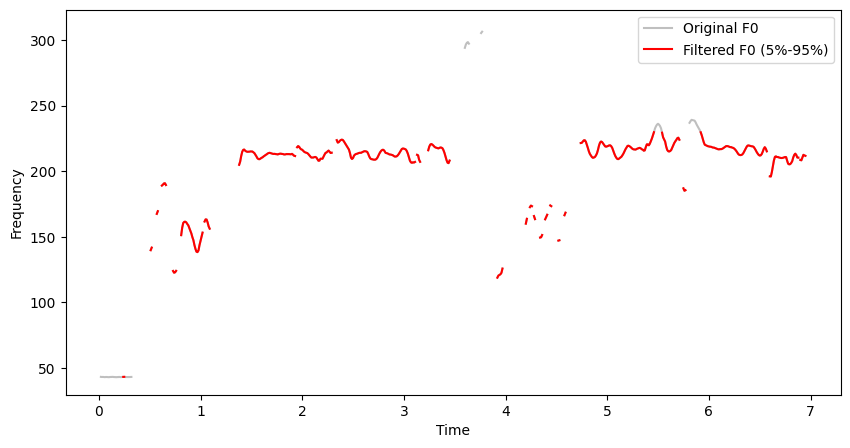

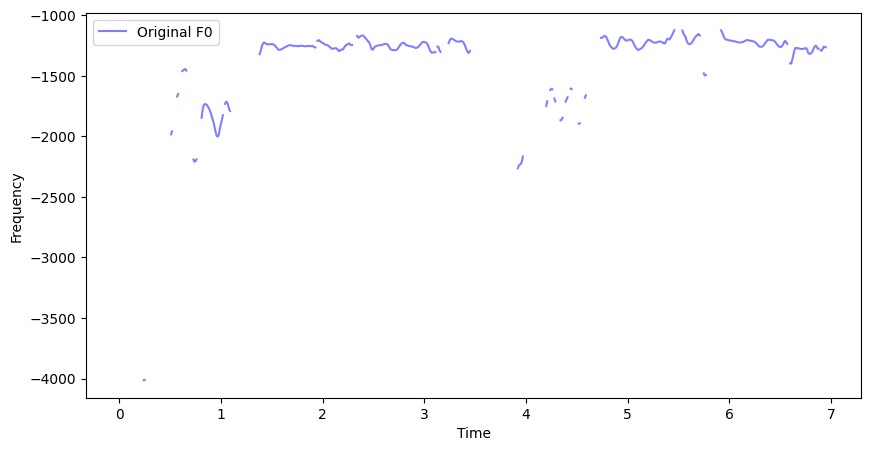

In [2]:
file_path ='/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/박봉술 춘향가 천자뒤풀이 김명환_3.csv'

df = pd.read_csv(file_path, header = None)

df.columns = ['Time', 'F0', 'Confidence']

df.loc[df["Confidence"] <= 0.7, "F0"] = np.nan

f0_values = df["F0"].to_numpy()
time_values = df["Time"].to_numpy()

lower_bound = np.nanpercentile(f0_values, 5)
upper_bound = np.nanpercentile(f0_values, 95)

filtered_f0 = np.where((f0_values < lower_bound) | (f0_values > upper_bound), np.nan, f0_values)

plt.figure(figsize=(10,5))
plt.plot(time_values, f0_values, label='Original F0', alpha=0.5, color='gray')
plt.plot(time_values, filtered_f0, label='Filtered F0 (5%-95%)', color='red')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

def freq_to_cent(freq):
    return 1200 * np.log2(freq / 440.0)

cent_values = freq_to_cent(filtered_f0)

plt.figure(figsize=(10,5))
plt.plot(time_values, cent_values, label='Original F0', alpha=0.5, color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

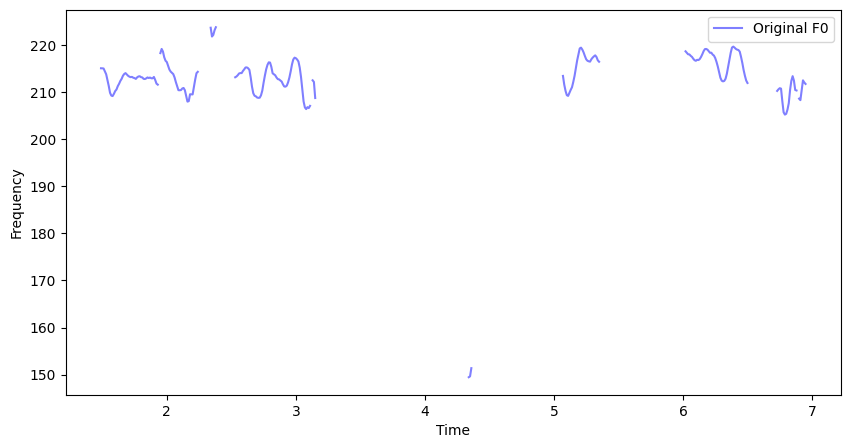

In [5]:
def freq_to_cent(freq):
    return 1200 * np.log2(freq / 440.0)

def cent_to_freq(cent):
    return 440.0 * (2 ** (cent / 1200))

def morphological_filter(frequency, time, window_size = 20, threshold = 90):

    """
    Applies morphological filtering to detect stable pitch regions

    Parameters:
    - frequency = pitch values in cents 
    - time = time values 
    - window_size: window size 
    - threshold: threshold in cents to define stability 
    
    Returns:
    -filtered_pitch: numpy array, stable pitch values 
    
    """
    gamma_max = scipy.ndimage.maximum_filter(frequency, size = window_size, mode = 'nearest')

    gamma_min = scipy.ndimage.minimum_filter(frequency, size = window_size, mode = 'nearest')

    morph_gradient = gamma_max - gamma_min

    stable_mask = np.abs(morph_gradient) <= threshold

    filtered_trajectory = np.where(stable_mask, frequency, np.nan)

    filtered_f0 = np.where(~np.isnan(filtered_trajectory), cent_to_freq(filtered_trajectory), np.nan)

    time_values = time 

    return filtered_f0, time_values

morph_filtered_freq, time_values = morphological_filter(cent_values, time_values)

plt.figure(figsize=(10,5))
plt.plot(time_values, morph_filtered_freq, label='Original F0', alpha=0.5, color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()



'''
Now Only mark the timezone where it is stable 

Mark what time is when the value is available 

Hear and see it with sonic visualizer 

'''
import csv
rows = zip(morph_filtered_freq, time_values)
csv_file_path ='/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/morph_filtered.csv'

with open(csv_file_path, 'w') as f:
    writer = csv.writer(f)
    for row in rows:
        writer.writerow(row)


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


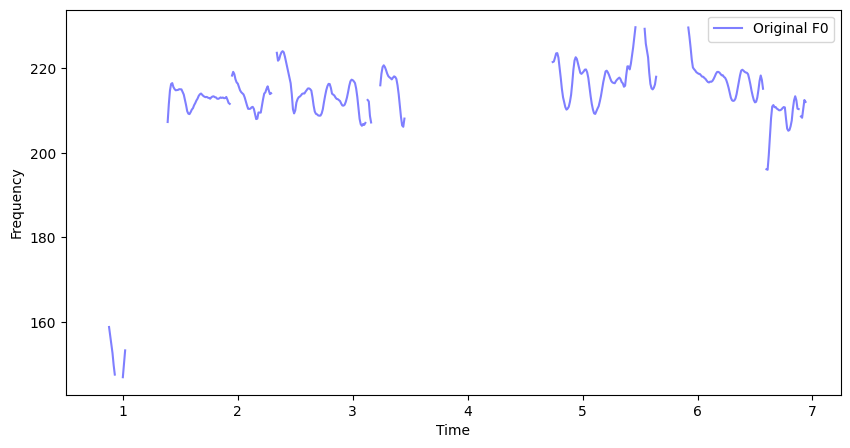

In [ ]:
frequency = filtered_f0

R = 10

valid_mask = ~np.isnan(frequency)

binned_freqs = np.full_like(frequency, np.nan, dtype=float)

binned_freqs[valid_mask] = np.round(frequency[valid_mask] / R).astype(int)

max_bin = np.nanmax(binned_freqs) + 1 

binary_mask = np.zeros((len(frequency), int(max_bin)), dtype = np.uint8)

for i, b in enumerate(binned_freqs):
    if not np.isnan(b) and b >= 0:
        binary_mask[i, int(b)] = 1

print(binary_mask)

T, F = binary_mask.shape
beta = 1 

binary_mask_copy = np.copy(binary_mask)

for t in range(T):
    for f in range(F): 
        if binary_mask[t, f] == 1:
            lower = max(0, f - beta)
            upper = min(F, f + beta + 1)
            binary_mask_copy[t, lower:upper] = 1

binary_mask_copy = median_filter(binary_mask_copy, size = (43, 1), mode = 'nearest')

masked_frequency = np.full_like(frequency, np.nan, dtype = float)

for i, b in enumerate(binned_freqs):
    if not np.isnan(b) and binary_mask_copy[i, int(b)] == 1:
        masked_frequency[i] = frequency[i]

plt.figure(figsize=(10,5))
plt.plot(time_values, masked_frequency, label='Original F0', alpha=0.5, color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

import csv
rows = zip(masked_frequency, time_values)
csv_file_path ='/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/mask_filtered.csv'

with open(csv_file_path, 'w') as f:
    writer = csv.writer(f)
    for row in rows:
        writer.writerow(row)